In [ ]:
# %% [markdown]
# # Modelo Naïve Bayes para Predicción de SMS
# Dataset: sms_spam_collection.csv
# Objetivo: predecir si un SMS es "ham" o "spam"

In [ ]:
# %% [markdown]
# ## 1. Cargar librerías y leer archivo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score

from sklearn.inspection import permutation_importance

# Leer archivo CSV
df = pd.read_csv("sms_spam_collection.csv")

# Ver primeras filas
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Filas y columnas: (5574, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5574 entries, 0 to 5573
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5574 non-null   object
 1   message  5574 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None
Columnas: Index(['label', 'message'], dtype='object')
Valores faltantes:
label      0
message    0
dtype: int64
Distribución de label:
label
ham     4827
spam     747
Name: count, dtype: int64


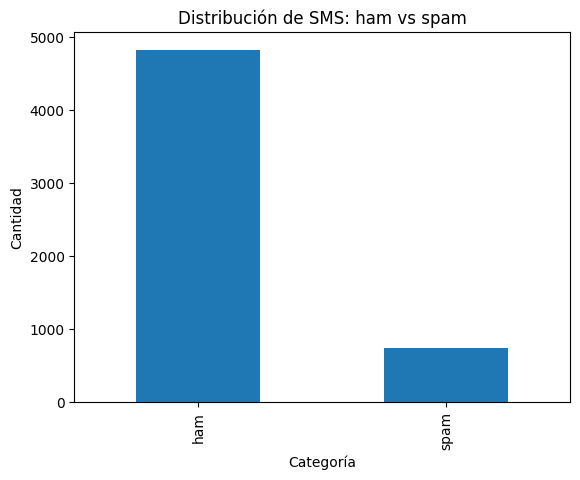

label
ham      71.438160
spam    138.634538
Name: message_length, dtype: float64


In [ ]:
# %% [markdown]
# ## 2. EDA básico

# Ver tamaño del dataset
print("Filas y columnas:", df.shape)

# Ver información general
print(df.info())

# Ver nombres de columnas
print("Columnas:", df.columns)

# Ver valores faltantes
print("Valores faltantes:")
print(df.isnull().sum())

# Ver distribución de la variable objetivo
print("Distribución de label:")
print(df["label"].value_counts())

# Gráfico de spam vs ham
df["label"].value_counts().plot(kind="bar")
plt.title("Distribución de SMS: ham vs spam")
plt.xlabel("Categoría")
plt.ylabel("Cantidad")
plt.show()

# Crear variable con la longitud del mensaje
df["message_length"] = df["message"].astype(str).str.len()

# Ver longitud promedio por categoría
print(df.groupby("label")["message_length"].mean())

In [ ]:
# %% [markdown]
# ## 3. Definir variable objetivo, X e y

# Definir X con el texto del mensaje
X = df["message"].astype(str)

# Definir y con la categoría ham/spam
y = df["label"]

# Codificar y porque es categórica
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Ver equivalencia de clases
print("Clases:", label_encoder.classes_)

# En este dataset no hay columnas no necesarias para el modelo principal
# La columna message es la variable explicativa
# La columna label es la variable objetivo

Clases: ['ham' 'spam']


In [ ]:
# %% [markdown]
# ## 4. Dividir en Training y Testing

# Dividir antes de transformar texto para evitar fuga de información
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test:", X_test.shape)

Tamaño X_train: (3901,)
Tamaño X_test: (1673,)


In [ ]:
# %% [markdown]
# ## 5. Imputación, transformación de texto y escalamiento

# Imputación simple para texto vacío
X_train = X_train.fillna("")
X_test = X_test.fillna("")

# Para texto no usamos OneHotEncoder
# Usamos CountVectorizer para convertir palabras en columnas numéricas
vectorizer = CountVectorizer(stop_words="english")

# Ajustar con training y transformar training
X_train_final = vectorizer.fit_transform(X_train)

# Transformar test con las mismas palabras aprendidas en training
X_test_final = vectorizer.transform(X_test)

# En Naïve Bayes para conteos de palabras no se escala
# MultinomialNB trabaja con frecuencias o conteos

# Ver tamaño final
print("Tamaño final X_train:", X_train_final.shape)
print("Tamaño final X_test:", X_test_final.shape)

# Ver algunas palabras convertidas en columnas
palabras = vectorizer.get_feature_names_out()
print("Primeras palabras:", palabras[:20])

Tamaño final X_train: (3901, 6917)
Tamaño final X_test: (1673, 6917)
Primeras palabras: ['00' '000' '000pes' '008704050406' '0089' '01223585334' '02' '0207'
 '02072069400' '02085076972' '021' '03' '04' '0430' '05' '050703' '0578'
 '06' '07' '07008009200']


In [ ]:
# %% [markdown]
# ## 6. Crear el Modelo Naïve Bayes, entrenar y predecir

# Crear modelo Naïve Bayes para conteo de palabras
modelo_nb = MultinomialNB()

# Entrenar modelo
modelo_nb.fit(X_train_final, y_train)

# Predecir categorías
y_pred = modelo_nb.predict(X_test_final)

# Predecir probabilidades para ROC
y_prob = modelo_nb.predict_proba(X_test_final)[:, 1]

Accuracy: 0.986252241482367
Matriz de Confusión:
[[1439   10]
 [  13  211]]
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99      1449
        spam       0.95      0.94      0.95       224

    accuracy                           0.99      1673
   macro avg       0.97      0.97      0.97      1673
weighted avg       0.99      0.99      0.99      1673

AUC: 0.9860032781228433


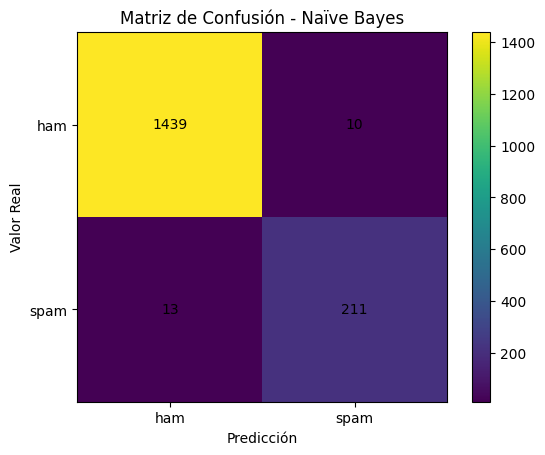

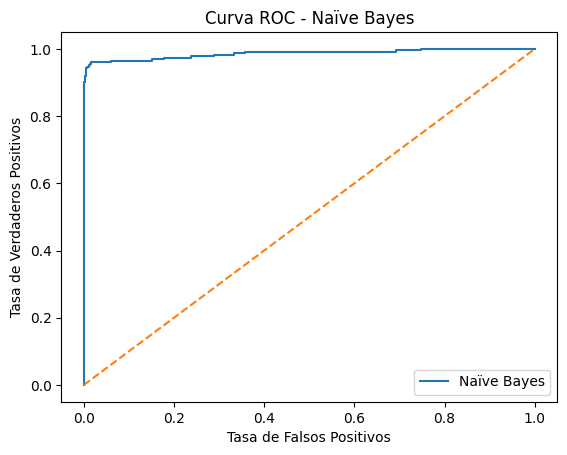

In [ ]:
# %% [markdown]
# ## 7. Métricas del Modelo

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Matriz de confusión
matriz = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:")
print(matriz)

# Reporte de clasificación
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# AUC
auc = roc_auc_score(y_test, y_prob)
print("AUC:", auc)

# Gráfico de matriz de confusión
plt.imshow(matriz)
plt.title("Matriz de Confusión - Naïve Bayes")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.xticks([0, 1], label_encoder.classes_)
plt.yticks([0, 1], label_encoder.classes_)

for i in range(matriz.shape[0]):
    for j in range(matriz.shape[1]):
        plt.text(j, i, matriz[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="Naïve Bayes")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("Curva ROC - Naïve Bayes")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.legend()
plt.show()

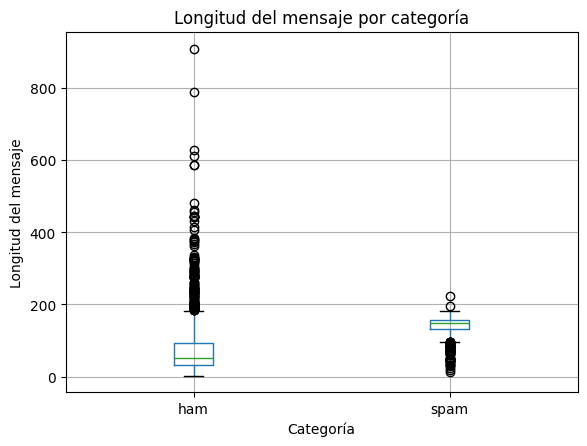

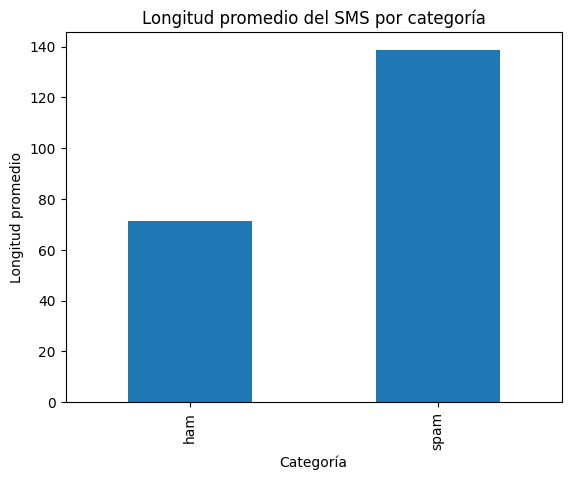

Ejemplos de spam:


,message
2,Free entry in 2 a wkly comp to win FA Cup fina...
5,FreeMsg Hey there darling it's been 3 week's n...
8,WINNER!! As a valued network customer you have...
9,Had your mobile 11 months or more? U R entitle...
11,"SIX chances to win CASH! From 100 to 20,000 po..."


Ejemplos de ham:


,message
0,"Go until jurong point, crazy.. Available only ..."
1,Ok lar... Joking wif u oni...
3,U dun say so early hor... U c already then say...
4,"Nah I don't think he goes to usf, he lives aro..."
6,Even my brother is not like to speak with me. ...


In [ ]:
# %% [markdown]
# ## 8. Visualizar datos

# Gráfico de longitud de mensajes por categoría
df.boxplot(column="message_length", by="label")

plt.title("Longitud del mensaje por categoría")
plt.suptitle("")
plt.xlabel("Categoría")
plt.ylabel("Longitud del mensaje")
plt.show()

# Promedio de longitud por categoría
df.groupby("label")["message_length"].mean().plot(kind="bar")

plt.title("Longitud promedio del SMS por categoría")
plt.xlabel("Categoría")
plt.ylabel("Longitud promedio")
plt.show()

# Ver algunos mensajes spam
print("Ejemplos de spam:")
display(df[df["label"] == "spam"]["message"].head())

# Ver algunos mensajes normales
print("Ejemplos de ham:")
display(df[df["label"] == "ham"]["message"].head())

,Palabra,Importancia_Spam
1645,claim,5.058228
4864,prize,4.779056
263,150p,4.508181
277,18,4.365081
6226,tone,4.312437
486,500,4.285038
1895,cs,4.256867
2961,guaranteed,4.198027
1061,awarded,4.033724
218,1000,3.997356


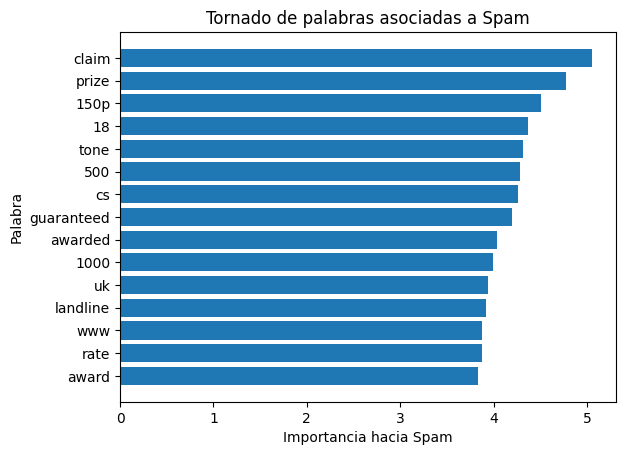

In [ ]:
# %% [markdown]
# ## 9. Tornado de Feature Importance

# Para texto, la importancia se puede interpretar con las probabilidades de palabras del modelo
# Vamos a comparar palabras más asociadas a spam vs ham

# Obtener nombres de palabras
palabras = vectorizer.get_feature_names_out()

# Obtener probabilidades logarítmicas de cada palabra por clase
log_prob_ham = modelo_nb.feature_log_prob_[0]
log_prob_spam = modelo_nb.feature_log_prob_[1]

# Calcular diferencia entre spam y ham
diferencia_spam = log_prob_spam - log_prob_ham

# Crear tabla de importancia
df_importancia = pd.DataFrame({
    "Palabra": palabras,
    "Importancia_Spam": diferencia_spam
})

# Ordenar palabras más asociadas a spam
df_importancia = df_importancia.sort_values("Importancia_Spam", ascending=False)

# Mostrar principales palabras
display(df_importancia.head(15))

# Gráfico tornado con palabras más asociadas a spam
top_spam = df_importancia.head(15).sort_values("Importancia_Spam")

plt.barh(top_spam["Palabra"], top_spam["Importancia_Spam"])
plt.title("Tornado de palabras asociadas a Spam")
plt.xlabel("Importancia hacia Spam")
plt.ylabel("Palabra")
plt.show()

In [ ]:
# %% [markdown]
# ## 10. Interfaz de Predicción Simple

# Cambiar este mensaje para probar el modelo
mensaje_nuevo = [
    "Your itinerary for trip is here"
]

#Congratulations! You won a free prize. Call now to claim your reward

# Convertir el mensaje nuevo usando el mismo vectorizer
mensaje_nuevo_final = vectorizer.transform(mensaje_nuevo)

# Predecir categoría
prediccion = modelo_nb.predict(mensaje_nuevo_final)

# Predecir probabilidades
probabilidad = modelo_nb.predict_proba(mensaje_nuevo_final)

# Convertir predicción numérica a texto
resultado = label_encoder.inverse_transform(prediccion)

print("Mensaje:", mensaje_nuevo[0])
print("Predicción:", resultado[0])
print("Probabilidad ham:", probabilidad[0][0])
print("Probabilidad spam:", probabilidad[0][1])

print("Conclusión:")
print("Naïve Bayes es útil para texto porque calcula qué palabras son más probables en cada categoría.")
print("En este caso, el modelo aprende palabras comunes en mensajes spam y mensajes normales.")
print("No usamos escalamiento porque el modelo trabaja con conteos de palabras.")
print("No usamos OneHotEncoder porque el texto se transforma mejor con CountVectorizer.")

Mensaje: Your itinerary for trip is here
Predicción: ham
Probabilidad ham: 0.8996695281168007
Probabilidad spam: 0.10033047188319949
Conclusión:
Naïve Bayes es útil para texto porque calcula qué palabras son más probables en cada categoría.
En este caso, el modelo aprende palabras comunes en mensajes spam y mensajes normales.
No usamos escalamiento porque el modelo trabaja con conteos de palabras.
No usamos OneHotEncoder porque el texto se transforma mejor con CountVectorizer.
